# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [6]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [7]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [8]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [9]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [10]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [11]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [12]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [13]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [14]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [15]:
# cantidad de nulos para users
print(users.isna().sum())
print("")
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [16]:
# cantidad de nulos para usage
print(usage.isna().sum())
print("")
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
**- ¿Qué columnas tienen valores faltantes y en qué proporción? Indica qué harías: ¿imputar, eliminar, ignorar?**
- En el archivo **`users`** hay dos columnas con valores faltantes:
    - *`City`* con *469* valores faltantes y una proporcion del *11.72%* se deben dejar como nulos debido a que no hay otra informacion que nos ayude a rellenar esos valores con precision.
    - *`Churn_date`* con *3,534* valores faltantes y una proporcion del *88.35%* se debe ignorar o elimiar en su totalidad la columna al ser la gran mayoria faltantes.

- En el archivo **usage** hay tres columnas con valores faltantes:
    - *`Date`* con *50* valores faltantes y una proporcion del *0.125%* se debe dejar como nulos al ser tan poquitos faltantes.
    - *`Duration`* con *22,076* valores faltantes y una proporcion del *55.19%* se debe ignorar ya que no deben haber valores en esta columna cuando la columna *`type`* es *`text.`* Es decir son esperados o normales esos valores faltantes.
    - *`Lenght`* con *17,896* valores faltantes y una proporcion del *44.74%* se debe ignorar debido a que no deben existir valores en esta columna cuando la columna *`type`* es *`call.`* Es decir son esperados o normales esos valores faltantes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [17]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` apesar de ser numerica, simplemente es un identificador unico de cada usuario. No amerita ningun analisis estadistico, solamente son 4,000 codigos diferentes de usuario.
- La columna `age` es la edad de los usuarios con un promedio de 33.74 años y un maximo de 79 años, pero hay un error en la edad minima -999.

In [18]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` apesar de ser numericas, simplemente son identificadores unicos. No ameritan ningun analisis estadistico, solamente son 4,000 resgistros diferentes.
- Las columnas `duration` y `length` son la duracion o la longitud de las llamadas o textos respectivamente. Ambas tienen un promedio, min y std cercano pero el max si esta muy lejano del resto de valores. 

In [19]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
   print(users[col].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` tiene 3 ciudades de Colombia escritas con la palabra completa y 3 ciudades de Mexico con solo la abreviatura de la ciudad. Ademas, tiene 96 valores con *"?"*.
- La columna `plan` solamente tiene dos opciones, *"Basico"* y *"Premium"*, no tiene ningun valor invalido.

In [20]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` tiene solamente dos opciones, *"text"* y *"call"*, no tiene ningun valor sentinel.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
**- ¿En qué columnas encontraste valores inválidos o sentinels? ¿Qué acción tomarías?** 
    - Unicamente en la columna `city` del archivo `users`se encuentran 96 valores invalidos "?". Se deben dejar como nulos debido a que no hay otra informacion que nos ayude a rellenar esos valores con precision.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [21]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors="coerce")

In [22]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors="coerce")

In [23]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se puede apreciar que hay 40 filas en donde el año es *2026*. Es decir que son valores invalidos ya que la información registrada debe ser **hasta el año 2024**.

In [24]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, todos los años registrados son en *2024.* 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
**- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)**
    - Asi es, en la columna `reg_date` de users aparecen 40 valores con el año *2026,* tiempo sin transcurrir al momento de guardar los datos.
**- ¿Qué harías con ellas?**
    - Se deben borrar esas filas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", np.nan)

# Verificar cambios
print(users['city'].describe())

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object


In [27]:
# Marcar fechas futuras como NA para reg_date
fechas_futuras = users['reg_date'].dt.year == 2026
users.loc[fechas_futuras, 'reg_date'] = np.nan

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [28]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [29]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

- En *`duration`*, para *`text`*, la media es 0.999276 — casi 1.0, lo que significa que la ausencia de datos depende de que la columna *`type`* sea *`text.`* Es decir son esperados o normales esos valores faltantes. En otra palabras, se clasifica como MAR (Missing at Random), debido a que depende del valor de otra columna observable.
- En *`lenght`* para *`call`*, la media es 0.99933 — casi 1.0, lo que significa que la ausencia de datos depende de que la columna  *`type`* sea *`text.`* Es decir son esperados o normales esos valores faltantes. En otra palabras, se clasifica como MAR (Missing at Random), debido a que depende del valor de otra columna observable.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({"is_text": "sum", "is_call":"sum", "duration":"sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text":"cant_mensajes", "is_call":"cant_llamadas", "duration":"cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [33]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [34]:
# Distribución porcentual del tipo de plan
users["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

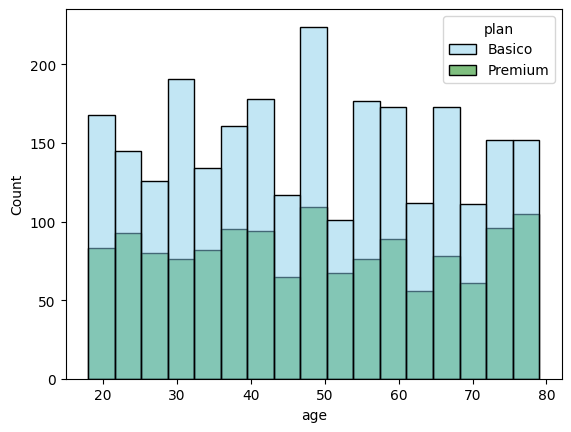

In [35]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.show()

💡Insights: 
- La distribución de edad se mantiene relativamente uniforme entre los 20 y 80 años para ambos planes, sin un sesgo marcado hacia ningún extremo; el plan Básico presenta una frecuencia mayor que el Premium en casi todos los rangos (reflejando una base de usuarios más grande en general), pero no se observa un patrón claro de que algún grupo de edad concentre preferencia por un plan sobre otro, lo que sugiere que la edad no es un factor determinante en la elección entre Básico y Premium.

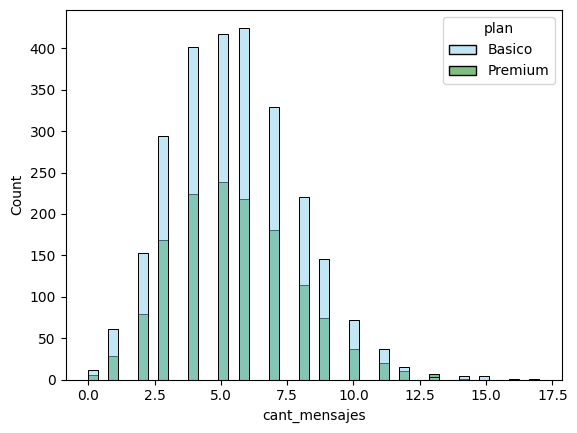

In [36]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.show()


💡Insights: 
- La cantidad de mensajes enviados presenta una distribución con sesgo hacia la derecha (cola larga hacia valores altos), concentrándose la mayoría de los usuarios entre 4 y 7 mensajes, tanto en el plan Básico como en el Premium; ambos planes muestran una forma de distribución muy similar y proporcional entre sí en todo el rango, sin evidencia de que un plan tienda sistemáticamente a enviar más o menos mensajes que el otro, lo que sugiere que no existe un patrón diferenciador claro entre Básico y Premium respecto a esta variable.

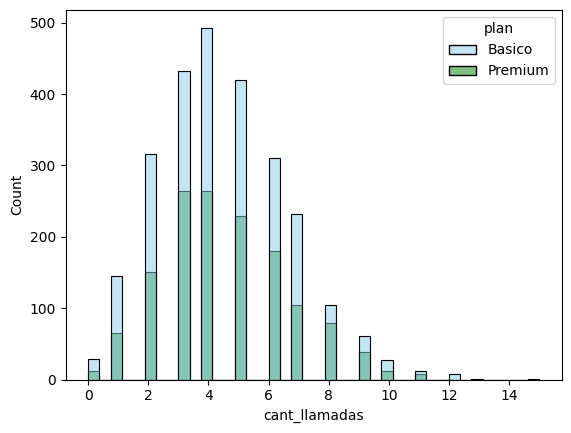

In [37]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.show()


💡Insights: 
- La cantidad de llamadas por usuario muestra una distribución con sesgo hacia la derecha, concentrándose la mayoría entre 2 y 6 llamadas y con una cola larga hacia valores altos poco frecuentes; al igual que con los mensajes, ambos planes (Básico y Premium) presentan una forma de distribución muy similar y proporciones comparables en todo el rango, sin evidencia de que un plan tienda a generar sistemáticamente más o menos llamadas que el otro, lo que sugiere que no existe un patrón diferenciador claro entre Básico y Premium respecto a esta variable.

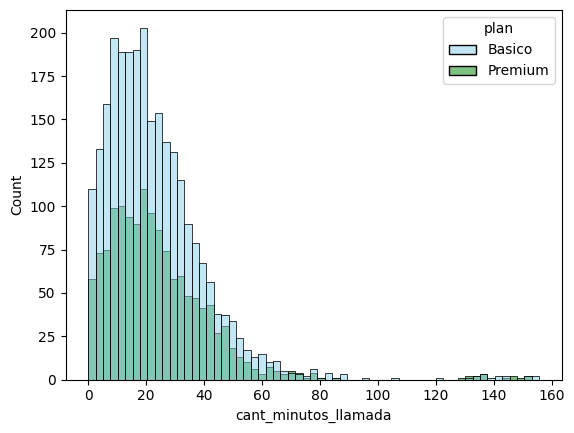

In [38]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.show()


💡Insights: 
- La duración de las llamadas presenta una distribución con sesgo pronunciado hacia la derecha, concentrándose la mayoría de las llamadas entre 10 y 30 minutos y con una cola larga y dispersa que se extiende hasta más de 140 minutos en casos poco frecuentes; ambos planes (Básico y Premium) mantienen una proporción similar y consistente a lo largo de todo el rango de duración, sin que se observe que un plan tienda a generar llamadas sistemáticamente más largas o más cortas que el otro, lo que sugiere que no existe un patrón diferenciador claro entre Básico y Premium respecto a esta variable.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

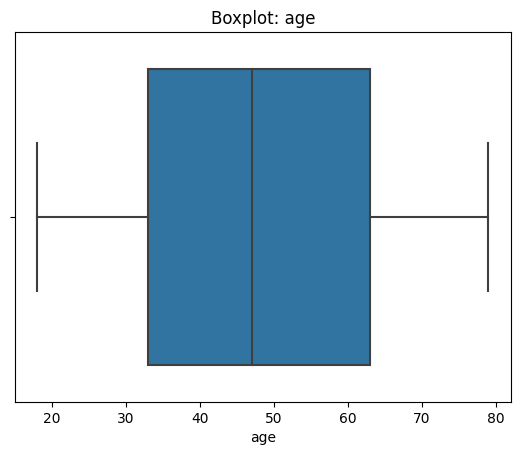

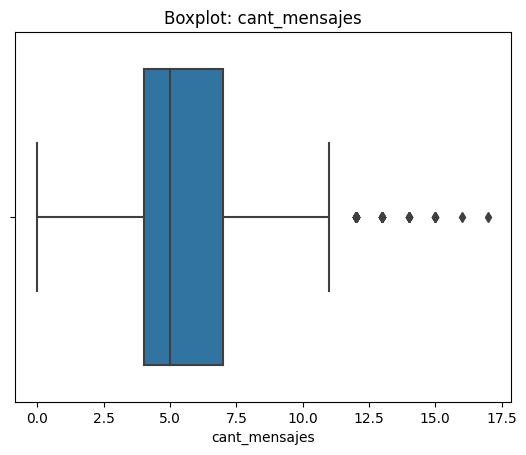

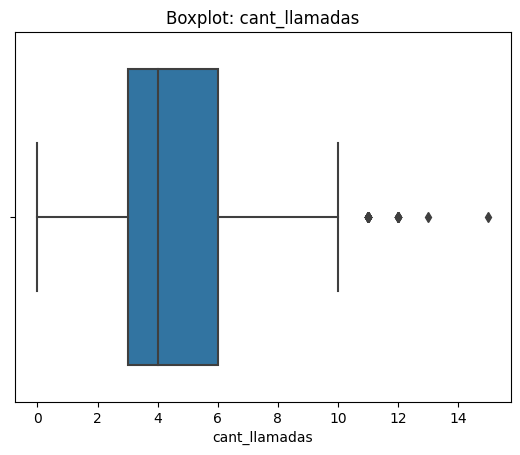

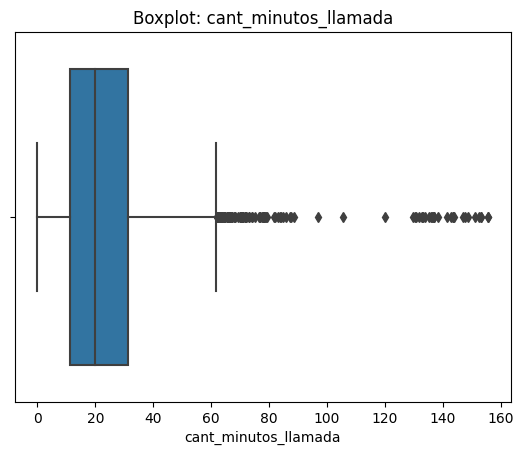

In [39]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data= user_profile, x= col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- **`Age`**: Claramente no se presentan outliers, todas las edades estan dentro del rango Q1 Y Q3.
- **`cant_mensajes`**: Evidentemente si existen outliers. Valores atipicos extremos superiores.
- **`cant_llamadas`**: Tambien se presentan outliers. Valores atipicos extremos por encima del Q4.
- **`cant_minutos_llamada`**: Es donde mayor outliers existen. Con claridad se ven muchos valores atipicos extremos superando el Q4.

In [40]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    upper_sum = (user_profile[col] > upper).sum()
    print(col, "tiene un limite superior de", upper, "y el total de outliers es", upper_sum)

cant_mensajes tiene un limite superior de 11.5 y el total de outliers es 46
cant_llamadas tiene un limite superior de 10.5 y el total de outliers es 30
cant_minutos_llamada tiene un limite superior de 61.8575 y el total de outliers es 109


In [41]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- **Mantener** los outliers de **`cant_mensajes`** y **`cant_llamadas`** porque en ambos casos, el máximo está relativamente cerca del límite superior (17 vs 11.5 y 15 vs 10.5, respectivamente) — no son valores desproporcionadamente alejados. Ademas, La cantidad de outliers es baja en proporción al total (46 y 30 sobre 3999 registros, ~1.1% y ~0.75%), y son valores plausibles (por ejemplo, alguien que envía 17 mensajes o hace 15 llamadas no es un dato irreal ni un error), por lo que probablemente representan comportamiento genuino de usuarios activos, no errores de captura.

- **Eliminar** los outliers de **`cant_minutos_llamada`** debido a que el máximo (155.69) está muy por encima del límite superior (61.86) — casi el triple, lo que indica valores extremadamente alejados del resto de los datos. Adicionalmente, tiene la mayor cantidad de outliers (109), y dado que la variable ya mostraba un fuerte sesgo a la derecha con cola larga, estos valores extremos pueden distorsionar la media y el desvío estándar de forma significativa.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [42]:
# Crear columna grupo_uso
user_profile["grupo_uso"] = np.where(
    (user_profile["cant_mensajes"] < 5) & (user_profile["cant_llamadas"] < 5),
    'Bajo uso', np.where(
        (user_profile["cant_mensajes"] < 10) & (user_profile["cant_llamadas"] < 10),
        'Uso medio', 'Alto uso'))

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [44]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where(
    user_profile["age"] < 30,
    'Joven', np.where(
        user_profile["age"] < 60,
        'Adulto', 'Adulto Mayor'))

In [45]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

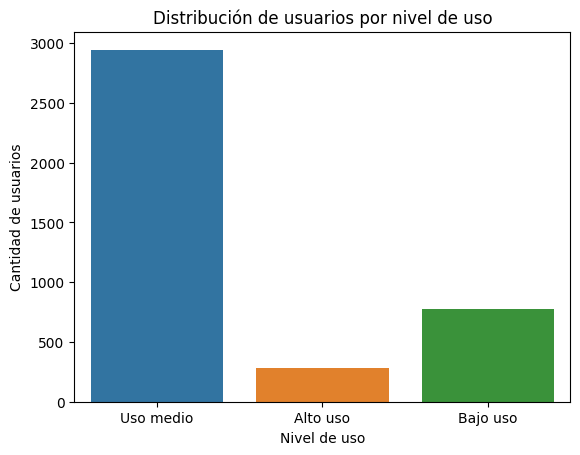

In [46]:
# Visualización de los segmentos por uso
sns.countplot(data = user_profile, x = "grupo_uso")
plt.title("Distribución de usuarios por nivel de uso")
plt.xlabel("Nivel de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()


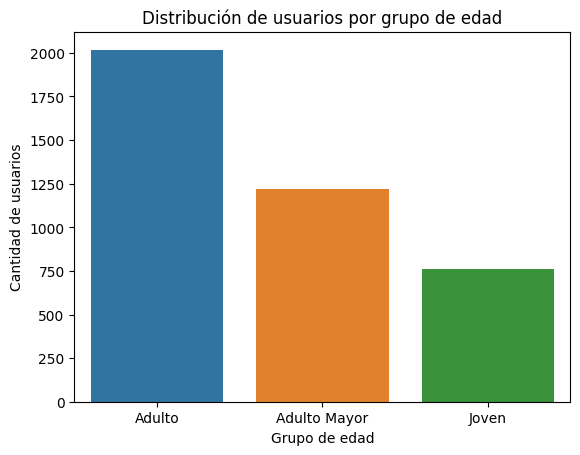

In [47]:
# Visualización de los segmentos por edad
sns.countplot(data = user_profile, x = "grupo_edad")
plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- **¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?**  ✅


- **¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?** ✅  
- **¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?** ✅
- **¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?** ✅


- **¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?** ✅

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En el archivo **`users`** hay dos columnas con valores faltantes:
    - `City` con *469* valores faltantes y una proporcion del *11.72%* se deben dejar como nulos debido a que no hay otra informacion que nos ayude a rellenar esos valores con precision.
    - `Churn_date` con *3,534* valores faltantes y una proporcion del *88.35%* se debe ignorar o elimiar en su totalidad la columna al ser la gran mayoria faltantes.

- En el archivo **usage** hay tres columnas con valores faltantes:
    - `Date` con *50* valores faltantes y una proporcion del *0.125%* se debe dejar como nulos al ser tan poquitos faltantes.
    - `Duration` con *22,076* valores faltantes y una proporcion del *55.19%* se debe ignorar ya que no deben haber valores en esta columna cuando la columna *`type`* es *`text.`* Es decir son esperados o normales esos valores faltantes.
    - `Lenght` con *17,896* valores faltantes y una proporcion del *44.74%* se debe ignorar debido a que no deben existir valores en esta columna cuando la columna *`type`* es *`call.`* Es decir son esperados o normales esos valores faltantes.


🔍 **Segmentos por Edad**
- Por edad (`grupo_edad`): *`Adulto`* (aprox. 2000), *`Adulto Mayor`* (aprox. 1250), *`Joven`* (aprox. 750). El Adulto es el grupo predominante, casi el triple que Joven. 


📊 **Segmentos por Nivel de Uso**
- Por nivel de uso (`grupo_uso`): *`Uso medio`* (aprox. 2950, mayoría abrumadora), *`Bajo uso`* (aprox. 800), *`Alto uso`* (aprox. 300, el más pequeño).



➡️ Esto sugiere que combinando ambas dimensiones: la base de usuarios es mayoritariamente adulta con un uso moderado de llamadas y mensajes, sin diferencias marcadas por plan (Básico/Premium) en las variables de comportamiento (mensajes, llamadas, minutos), lo que sugiere que la elección de plan no está correlacionada fuertemente con el patrón de uso ni con la edad.

⭐ **Segmentos más valiosos**
- *`Adulto`* + *`Uso medio`*: el segmento más grande y estable — representa el "núcleo" de la base de clientes, ideal para retención y fidelización.
- *`Alto uso`* (independiente de edad): aunque es el grupo más pequeño (~300 usuarios), es el de mayor potencial de ingreso por cliente (ARPU) si se les ofrece un plan que capture su consumo real — actualmente podrían estar sub-monetizados si están en plan Básico.

📈 **Patrones de Uso Extremo (Outliers)**
- `cant_minutos_llamada` tenía 109 outliers (~2.7% de 3999 registros), con un máximo de 155.69 min frente a un límite superior de 61.86 — se decidió eliminarlos por estar muy alejados del resto de la distribución.
    - La duración de llamadas mostró los outliers más extremos (hasta 155 min vs. un límite de ~62 min), indicando un pequeño grupo de usuarios con llamadas anormalmente largas — podría tratarse de un uso atípico (ej. líneas usadas para trabajo/call center) o errores de registro.
- `cant_mensajes` (46 outliers, ~1.1%) y `cant_llamadas` (30 outliers, ~0.75%) se conservaron por ser valores plausibles y cercanos al límite superior
    - Mensajes y llamadas tuvieron outliers más moderados y creíbles, reflejando usuarios genuinamente muy activos más que errores de datos.
  
➡️ Esto sugiere que el segmento de llamadas extremadamente largas merece investigarse aparte — podría requerir un plan especializado (ej. "Plan Ilimitado" o tarifa por uso intensivo) en vez de ser tratado como ruido
  


💡 **Recomendaciones**
- **Crear un plan "Alto Uso" o "Ilimitado"** dirigido al segmento de uso intensivo (aprox. 300 usuarios), con tarifas ajustadas a su consumo real de minutos, para capturar mejor su valor y evitar fuga a la competencia.
- **Revisar la segmentación Básico/Premium:** dado que no se observan diferencias claras de comportamiento entre planes, la diferenciación actual podría no estar basada en las variables correctas (uso real) — conviene rediseñar los planes en torno a grupo_uso en vez de (o además de) las características actuales.
- **Foco en retención del segmento Adulto + Uso medio**: al ser el núcleo de la base, pequeñas mejoras en su experiencia (precio, beneficios) tendrán el mayor impacto agregado.
- **Investigar el subgrupo de llamadas extremadamente largas** para entender su perfil (¿uso personal intensivo? ¿uso comercial no declarado?) y diseñar una oferta específica si es un patrón recurrente y no un error de datos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`